# Modelo ARIMA
En este notebook implementamos el modelo **ARIMA** (AutoRegressive Integrated Moving Average) para resolver el problema de predicción de ventas planteado.
El objetivo es utilizar los datos históricos para predecir las ventas diarias entre el 9 de noviembre y el 9 de diciembre de 2011.
Para evaluar su éxito, no solo compararemos la predicción con la realidad, sino que analizaremos la naturaleza de sus errores para asegurar que el modelo no presenta sesgos sistemáticos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

# [DOC] Cargamos de datos, aseguramos la freciencia diaria  y rellenamos huecos
df_train = pd.read_csv('../../../data/processed/train_data.csv', parse_dates=['Date'], index_col='Date')
df_test = pd.read_csv('../../../data/processed/test_data.csv', parse_dates=['Date'], index_col='Date')

df_train = df_train.asfreq('D').fillna(0)
df_test = df_test.asfreq('D').fillna(0)

y_train = df_train['Sales']
y_test = df_test['Sales']

print(f"[INFO] Datos de Entrenamiento: {len(y_train)} días | Datos de Test: {len(y_test)} días")

[INFO] Datos de Entrenamiento: 335 días | Datos de Test: 31 días


In [2]:
# [DOC] Procedemos a generar y entrenar el modelo, para ello, definimos el orden: p (lags), d (diferenciación), q (media móvil)

model = ARIMA(y_train, order=(5, 1, 0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                  335
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -3539.043
Date:                Sat, 11 Apr 2026   AIC                           7090.087
Time:                        18:11:15   BIC                           7112.954
Sample:                    12-09-2010   HQIC                          7099.204
                         - 11-08-2011                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4605      0.044    -10.469      0.000      -0.547      -0.374
ar.L2         -0.5770      0.049    -11.759      0.000      -0.673      -0.481
ar.L3         -0.4828      0.059     -8.220      0.0

In [3]:
# [DOC] generamos predicción para los días de test
forecast_res = model_fit.get_forecast(steps=len(y_test))
forecast_mean = forecast_res.summary_frame()['mean']
conf_int = forecast_res.summary_frame(alpha=0.05)

In [9]:
# [DOC] Calculamos métricas para el reporte
rmse = np.sqrt(mean_squared_error(y_test, forecast_mean))
mae = mean_absolute_error(y_test, forecast_mean)
mask = y_test != 0
mape = np.mean(np.abs((y_test[mask] - forecast_mean[mask]) / y_test[mask])) * 100

print(f"--- RESULTADOS FINALES ---")
print(f"RMSE: {rmse:.2f} (Castiga errores grandes)")
print(f"MAE:  {mae:.2f} (Error medio en Euros)")
print(f"MAPE: {mape:.2f}% (Error relativo porcentual)")
print(f"--------------------------")

--- RESULTADOS FINALES ---
RMSE: 15451.38 (Castiga errores grandes)
MAE:  12795.92 (Error medio en Euros)
MAPE: 30.15% (Error relativo porcentual)
--------------------------


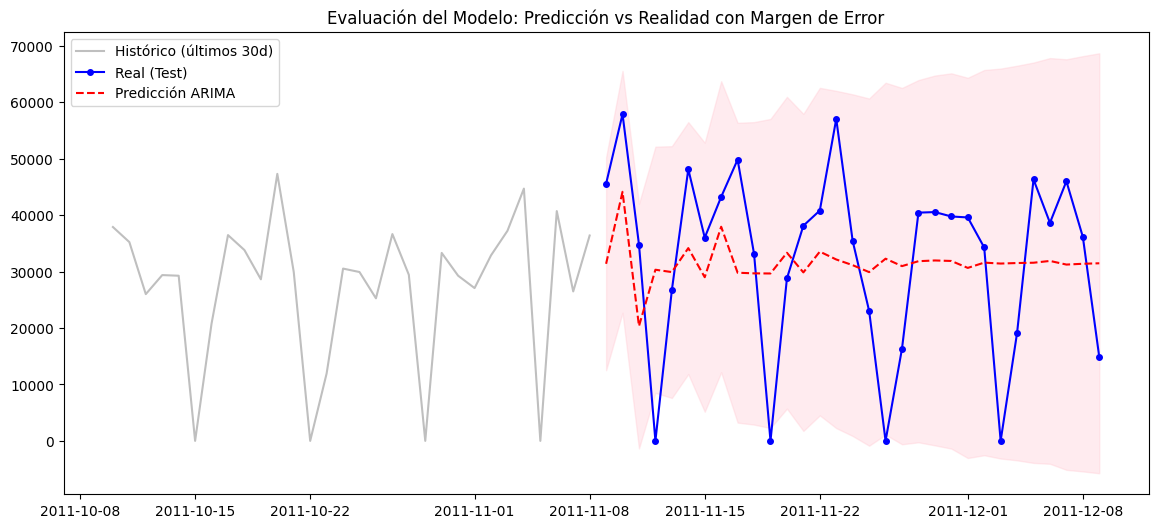

In [ ]:
# [DOC] Gráfica de Realidad vs Predicción + Incertidumbre

plt.figure(figsize=(14, 6))
plt.plot(y_train[-30:], label='Histórico (últimos 30d)', color='gray', alpha=0.5)
plt.plot(y_test.index, y_test, label='Real (Test)', color='blue', marker='o', markersize=4)
plt.plot(y_test.index, forecast_mean, label='Predicción ARIMA', color='red', linestyle='--')

plt.fill_between(y_test.index, conf_int['mean_ci_lower'], conf_int['mean_ci_upper'], color='pink', alpha=0.3)

plt.title('Evaluación del Modelo: Predicción vs Realidad con Margen de Error')
plt.legend()
plt.show()


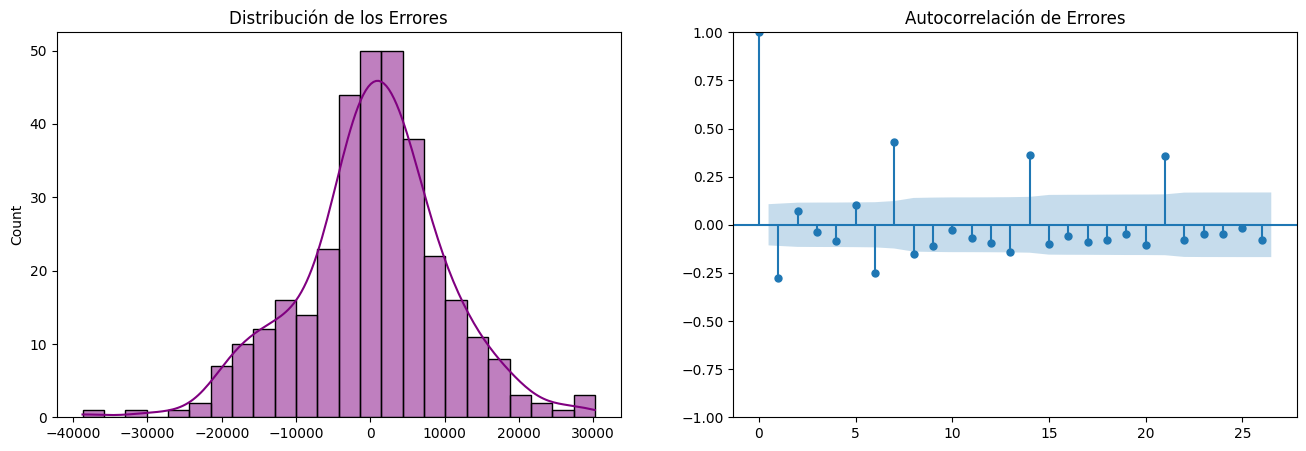

In [ ]:
# [DOC] Análisis de Residuos (Errores). Si el modelo es bueno, los errores deben ser aleatorios

residuals = model_fit.resid
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

sns.histplot(residuals, kde=True, ax=ax[0], color='purple')
ax[0].set_title('Distribución de los Errores')

from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, ax=ax[1])
ax[1].set_title('Autocorrelación de Errores')

plt.show()

In [8]:
# [DOC] Guardamos el objeto del modelo entrenado y el resumen de métricas

model_dir = '../../models'

if not os.path.exists(model_dir):
    os.makedirs(model_dir, exist_ok=True)
    print(f"[INFO] Carpeta de modelos creada: {model_dir}")

model_filename = os.path.join(model_dir, 'arima_sales_model_v1.pkl')
metrics = {'rmse': rmse, 'mae': mae, 'mape': mape}

joblib.dump({'model': model_fit, 'metrics': metrics}, model_filename)

print(f"[SUCCESS] Modelo guardado correctamente en: {model_filename}")

[INFO] Carpeta de modelos creada: ../../models
[SUCCESS] Modelo guardado correctamente en: ../../models\arima_sales_model_v1.pkl
